# Análisis comparativo de los modelos entrenados

**Experimento:** `20260809_004420` · partición semilla 42 · nueve corridas
**Documento hermano:** [`analisis-mobilenetv2.ipynb`](analisis-mobilenetv2.ipynb),
que analiza el modelo **desplegado** y motivó este experimento.

Aquel cuaderno terminó con un diagnóstico: el MobileNetV2 en producción daba
98,43 % en su propio dataset y **71,60 %** con la cámara del robot. Este
documento evalúa la corrección: reconstruir el dataset y reentrenar tres
arquitecturas para ver cuánto de esa brecha se cierra.

## Contenido

1. Qué se compara y por qué esas tres arquitecturas
2. Los datos y su partición inmutable
3. Diseño experimental
4. Resultados de validación
5. Comportamiento durante el entrenamiento
6. Verificación de cuantización (criterio 4)
7. Criterios de aceptación y recomendación

### Cómo ejecutar este cuaderno

Requiere `requirements-dev.txt` y lee los artefactos ligeros de
`docs/resultados-vision/2026-08-09/`. No necesita el dataset ni los pesos.

## 0. Preparación del entorno

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

# ── Paleta ────────────────────────────────────────────────────────────────
# Validada para las tres formas de daltonismo (deuteranopía, protanopía,
# tritanopía) antes de usarse: el peor par mide ΔE 24,7, muy por encima del
# umbral de 8. El color nunca es el único canal: todas las barras van rotuladas.
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
APAGADO, REJILLA, BASE     = "#898781", "#e1e0d9", "#c3c2b7"

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # slots categóricos 1-3
CRITICO, BUENO      = "#d03b3b", "#0ca30c"              # estados

RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Divergente para correlaciones: rojo (negativa) ← gris (nula) → azul (positiva)
RAMPA_DIV  = ["#8c2020", "#d03b3b", "#e89a9a", "#f0efec", "#9ec5f4", "#2a78d6", "#104281"]

CMAP_SEC = LinearSegmentedColormap.from_list("azul", RAMPA_AZUL)
CMAP_DIV = LinearSegmentedColormap.from_list("div", RAMPA_DIV)

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10, "text.color": TINTA,
    "axes.labelcolor": TINTA_2, "axes.edgecolor": BASE, "axes.linewidth": 0.8,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlepad": 12, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8,
    "xtick.color": APAGADO, "ytick.color": APAGADO,
    "xtick.labelcolor": TINTA_2, "ytick.labelcolor": TINTA_2,
    "legend.frameon": False, "figure.dpi": 110,
})


def limpiar(ax, eje_y=True):
    """Marco recesivo: sin bordes superior/derecho, rejilla en un solo eje."""
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(BASE)
    ax.spines["bottom"].set_color(BASE)
    ax.xaxis.grid(not eje_y)
    ax.yaxis.grid(eje_y)
    ax.tick_params(length=0)
    return ax


def poner_titulo(ax, texto, subtitulo=""):
    """Título con subtítulo debajo. Las distancias van en puntos tipográficos,
    no en fracción de eje, para que no se solapen a ninguna altura de figura."""
    ax.set_title(texto, loc="left", pad=30 if subtitulo else 12)
    if subtitulo:
        ax.annotate(subtitulo, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 10), textcoords="offset points",
                    ha="left", va="bottom", color=TINTA_2, fontsize=10)


def matriz_confusion(ax, cm, clases, titulo, subtitulo=""):
    """Mapa de calor de una matriz de confusión (rampa secuencial de un tono)."""
    pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(pct, cmap=CMAP_SEC, vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}\n{pct[i, j]*100:.1f} %",
                    ha="center", va="center", fontsize=11,
                    color="#ffffff" if pct[i, j] > 0.55 else TINTA,
                    fontweight="bold" if i == j else "normal")
    ax.set_xticks(range(len(clases)), [f"predijo\n{c}" for c in clases])
    ax.set_yticks(range(len(clases)), [f"real\n{c}" for c in clases])
    poner_titulo(ax, titulo, subtitulo)
    ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)


MODELO_DIR = Path.cwd()
if MODELO_DIR.name != "model":
    MODELO_DIR = next((p for p in (Path("ia/vision-service/model"), Path("model"))
                       if p.exists()), MODELO_DIR)

print("Carpeta del modelo:", MODELO_DIR.resolve())
print("Archivos:", sorted(p.name for p in MODELO_DIR.glob("*") if p.is_file()))

Carpeta del modelo: C:\Users\acamp\Reci\ia\vision-service\model
Archivos: ['PROPUESTA-NUEVO-MODELO.md', 'README.md', 'analisis-mobilenetv2.ipynb', 'analisis-modelos-entrenados.ipynb', 'entrenamiento_manifest.json', 'labels.txt', 'model.tflite']


In [2]:
from pathlib import Path
import csv, json

RESULTADOS = Path("../../../docs/resultados-vision/2026-08-09")
if not RESULTADOS.is_dir():
    raise SystemExit(f"No se encuentra {RESULTADOS.resolve()}")

with (RESULTADOS / "resumen_comparacion.csv").open(encoding="utf-8", newline="") as fh:
    CORRIDAS = list(csv.DictReader(fh))
ESTADISTICO = json.loads((RESULTADOS / "resumen_estadistico.json").read_text(encoding="utf-8"))
GANADOR = json.loads((RESULTADOS / "ganador_validacion.json").read_text(encoding="utf-8"))

ARQ = ["mobilenetv2", "efficientnetb0", "mobilenetv3large"]
NOMBRE = {"mobilenetv2": "MobileNetV2", "efficientnetb0": "EfficientNet-B0",
          "mobilenetv3large": "MobileNetV3-Large"}
COLOR = {"mobilenetv2": AZUL, "efficientnetb0": APAGADO, "mobilenetv3large": NARANJA}

def stat(arq, metrica, campo="media"):
    fila = next(e for e in ESTADISTICO if e["arquitectura"] == arq)
    return fila["estadisticas_validacion"][metrica][campo]

def metricas_de(run_id):
    ruta = RESULTADOS / "metricas" / f"{run_id}_validacion_metricas.json"
    return json.loads(ruta.read_text(encoding="utf-8"))

print(f"{len(CORRIDAS)} corridas cargadas")
print(f"Ganador por validación: {GANADOR['ganador']['run_id']}")
print(f"Prueba reservada consultada: {GANADOR['prueba_reservada_consultada']}")

9 corridas cargadas
Ganador por validación: mobilenetv3large_20260809_004420_split42_seed1
Prueba reservada consultada: False


# 1. Qué se compara y por qué

## 1.1. El experimento

Tres arquitecturas × tres semillas de entrenamiento = **nueve corridas**, todas
con las mismas particiones, aumentos y presupuesto de ajuste. Esa igualdad es
lo que permite atribuir las diferencias a la arquitectura y no al azar del
procedimiento.

| ID | Arquitectura | Papel |
| --- | --- | --- |
| E1 | MobileNetV2 | **Control** — la arquitectura ya desplegada |
| E2 | EfficientNet-B0 | Candidato principal |
| E3 | MobileNetV3-Large | Candidato eficiente |

E1 es la pieza clave del diseño: al reentrenar la arquitectura actual con los
datos nuevos, separa **cuánta mejora viene de los datos** de cuánta viene de
cambiar de modelo. Sin ese control, cualquier ganancia se atribuiría por
defecto a la arquitectura nueva.

## 1.2. En qué se diferencian las tres

Las tres son redes convolucionales ligeras que parten de pesos de ImageNet
(*transfer learning*). Sus diferencias caben en tres rasgos:

| | MobileNetV2 | EfficientNet-B0 | MobileNetV3-Large |
| --- | --- | --- | --- |
| Parámetros | ≈ 3,5 M | ≈ 5,3 M | ≈ 5,4 M |
| Atención de canales | **No** | Sí (*squeeze-and-excitation*) | Sí |
| Activación | **ReLU6** (acotada) | Swish | hard-swish |
| Diseño | Manual | Escalado compuesto | Búsqueda de arquitectura (NAS) |

La **atención de canales** es la hipótesis del experimento: permite a la red
ponderar qué canales importan en cada región, algo que MobileNetV2 no tiene. Si
distinguir plástico transparente de vidrio depende de reflejos sutiles, debería
ayudar.

La fila de la **activación** parece un detalle técnico menor. En la sección 6
resulta ser decisiva.

# 2. Los datos

## 2.1. Composición

El dataset de trabajo combina dos orígenes, y la diferencia importa:

- **Externas** — el dataset anterior, de otra cámara. Aportan volumen.
- **Sesiones de ESP32-CAM** — capturas de la cámara real del robot. Aportan
  representatividad del dominio de producción.

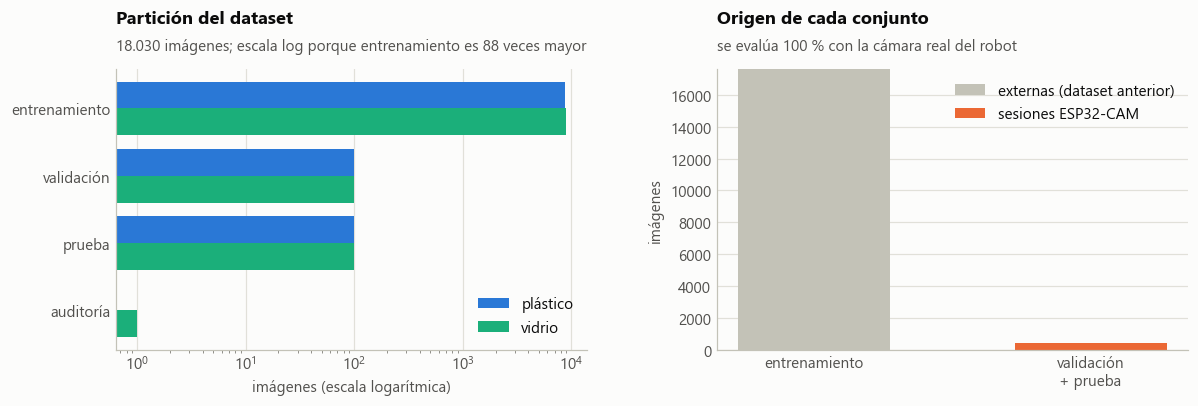

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

conjuntos = ["entrenamiento", "validación", "prueba", "auditoría"]
plastico = [8765, 100, 100, 0]
vidrio   = [8865,  99, 100, 1]
y = np.arange(len(conjuntos))

ax1.barh(y - 0.2, plastico, 0.4, label="plástico", color=AZUL)
ax1.barh(y + 0.2, vidrio,   0.4, label="vidrio",  color=AQUA)
ax1.set_yticks(y); ax1.set_yticklabels(conjuntos)
ax1.set_xscale("log"); ax1.set_xlabel("imágenes (escala logarítmica)")
ax1.invert_yaxis(); ax1.legend(loc="lower right")
limpiar(ax1, eje_y=False)
poner_titulo(ax1, "Partición del dataset",
             "18.030 imágenes; escala log porque entrenamiento es 88 veces mayor")

# Origen: entrenamiento se apoya en el dataset viejo, la evaluación no
ax2.bar(["entrenamiento", "validación\n+ prueba"], [17630, 0], 0.55,
        label="externas (dataset anterior)", color=BASE)
ax2.bar(["entrenamiento", "validación\n+ prueba"], [0, 399], 0.55,
        bottom=[17630, 0], label="sesiones ESP32-CAM", color=NARANJA)
ax2.set_ylabel("imágenes")
ax2.legend(loc="upper right")
limpiar(ax2)
poner_titulo(ax2, "Origen de cada conjunto",
             "se evalúa 100 % con la cámara real del robot")
plt.tight_layout(); plt.show()

### Lectura del resultado

La segunda gráfica contiene el dato metodológico más importante de todo el
experimento: **validación y prueba son íntegramente capturas de la ESP32-CAM.**

Es decir, todas las métricas de este cuaderno están medidas sobre el dominio
real del robot. Cuando en la sección 4 se lea «90,28 %», no es un número de
laboratorio: es la cámara que llevará puesta el robot.

Esto hace directamente comparable el resultado con el 71,60 % del cuaderno
hermano, porque ambos se midieron sobre el mismo tipo de imagen.

Contrapartida honesta: el entrenamiento sigue apoyado casi por completo en el
dataset anterior. Los modelos aprenden sobre todo de otro dominio y se evalúan
en el propio.

## 2.2. Partición inmutable

La asignación vive en `split_manifest.json` con semilla 42 y se hace **por
sesión completa**, nunca por foto suelta.

La razón: la ESP32-CAM captura ráfagas de fotos casi idénticas con dos segundos
de diferencia. Repartirlas al azar pondría la foto 001 en entrenamiento y la
002 en prueba; el modelo la reconocería de memoria y la prueba mediría memoria,
no generalización.

El cargador rechaza el dataset si detecta un SHA-256 repetido entre conjuntos,
una sesión partida en dos, una partición vacía o una clase ausente. La fuga de
datos no se evita por disciplina: se evita por construcción.

# 3. Diseño experimental

## 3.1. Procedimiento

Idéntico en las nueve corridas:

1. **Fase 1 — cabeza.** Backbone congelado, tasa `1e-3`. La capa final parte de
   valores aleatorios; entrenarla sola evita que sus errores iniciales destruyan
   los pesos heredados de ImageNet.
2. **Fase 2 — ajuste fino.** Se descongela el último 30 % del backbone con tasa
   `1e-5`, cien veces menor. Las capas de `BatchNormalization` siguen congeladas:
   con lotes pequeños, actualizar sus estadísticas desestabiliza el ajuste.
3. **Selección.** Parada temprana y mejor punto de control por **macro-F1 de
   validación**, no por exactitud.

## 3.2. Por qué macro-F1 y no exactitud

La exactitud promedia sobre las clases y puede esconder que una funciona mal.
Es exactamente lo que ocurrió con el modelo desplegado: 71,60 % global ocultaba
un recall de plástico del 60,60 %.

El macro-F1 promedia el F1 de cada clase **dando el mismo peso a ambas**, así
que una clase débil arrastra la métrica hacia abajo en lugar de diluirse.

## 3.3. Por qué tres semillas

Entrenar tiene componentes aleatorios: la inicialización de la cabeza y el
orden de los lotes. Dos corridas idénticas dan resultados algo distintos.

Con una sola corrida por arquitectura no habría forma de saber si una diferencia
es real o azar. Con tres se puede reportar media y desviación, y comprobar si
los rangos se solapan.

# 4. Resultados de validación

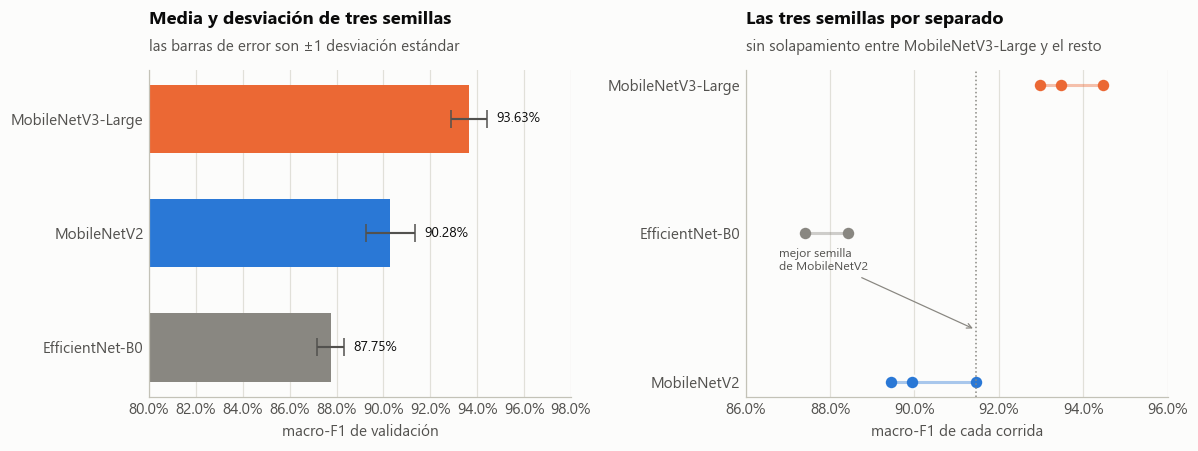

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

medias = [stat(a, "val_macro_f1") for a in ARQ]
desv   = [stat(a, "val_macro_f1", "desviacion_estandar") for a in ARQ]
orden  = np.argsort(medias)
y = np.arange(len(ARQ))

ax1.barh(y, [medias[i] for i in orden], 0.6,
         xerr=[desv[i] for i in orden], capsize=6,
         color=[COLOR[ARQ[i]] for i in orden],
         error_kw=dict(lw=1.4, ecolor=TINTA_2))
ax1.set_yticks(y); ax1.set_yticklabels([NOMBRE[ARQ[i]] for i in orden])
ax1.set_xlim(0.80, 0.98); ax1.set_xlabel("macro-F1 de validación")
ax1.xaxis.set_major_formatter(PercentFormatter(1.0))
for k, i in enumerate(orden):
    ax1.text(medias[i] + desv[i] + 0.004, k, f"{medias[i]:.2%}", va="center",
             fontsize=9, color=TINTA)
limpiar(ax1, eje_y=False)
poner_titulo(ax1, "Media y desviación de tres semillas",
             "las barras de error son ±1 desviación estándar")

# Semilla a semilla: comprobar si los rangos se solapan
for a in ARQ:
    vals = sorted(float(c["val_macro_f1"]) for c in CORRIDAS if c["arquitectura"] == a)
    ax2.plot(vals, [NOMBRE[a]] * 3, "o", color=COLOR[a], markersize=9,
             markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
    ax2.plot([vals[0], vals[-1]], [NOMBRE[a]] * 2, "-", color=COLOR[a], lw=2, alpha=0.4)
ax2.set_xlim(0.86, 0.96); ax2.set_xlabel("macro-F1 de cada corrida")
ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
ax2.axvline(0.9145, ls=":", color=APAGADO, lw=1)
ax2.annotate("mejor semilla\nde MobileNetV2", xy=(0.9145, 0.35), xytext=(0.868, 0.75),
             fontsize=8, color=TINTA_2,
             arrowprops=dict(arrowstyle="->", color=APAGADO, lw=0.8))
limpiar(ax2, eje_y=False)
poner_titulo(ax2, "Las tres semillas por separado",
             "sin solapamiento entre MobileNetV3-Large y el resto")
plt.tight_layout(); plt.show()

### Lectura del resultado

**MobileNetV3-Large gana en validación** con 93,63 % ± 0,77, y la ventaja es
sólida: su **peor** semilla (92,96 %) supera a la **mejor** de MobileNetV2
(91,45 %). Los rangos no se solapan, así que la diferencia no es ruido de
inicialización.

EfficientNet-B0 quedó último, por debajo del control. Su mayor capacidad no se
tradujo en mejor desempeño con este volumen de datos.

Pero el resultado más importante de esta gráfica es otro, y no se ve en ella:

```
MobileNetV2 de julio (mismo tipo de fotos)   →  71,60 %
MobileNetV2 reentrenado                      →  90,28 %
```

**Casi 19 puntos, sin cambiar de arquitectura.** La mejora vino de reconstruir
el dataset y de la partición honesta, no de un modelo mejor. Para eso existía el
control E1, y su respuesta es inequívoca.

Frente a esos 19 puntos ganados por datos, los 3,35 que aporta MobileNetV3-Large
son un margen modesto.

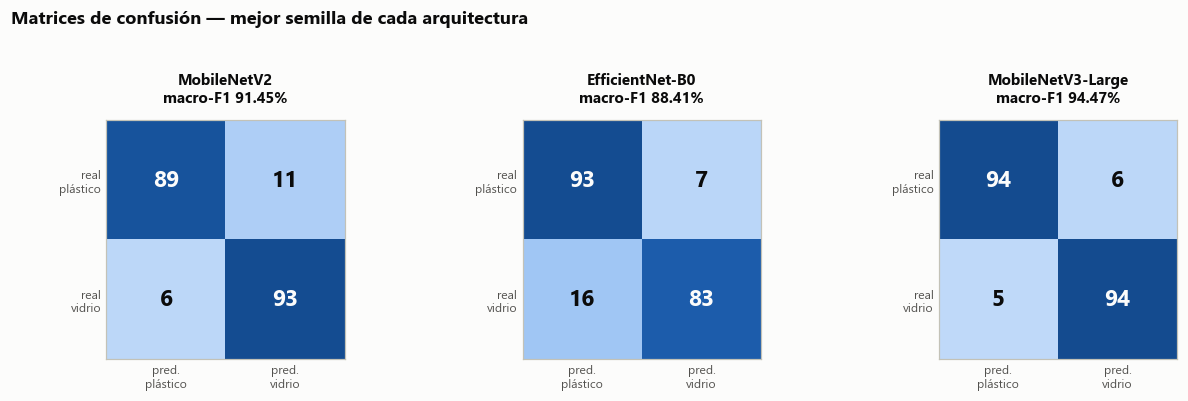

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
mejores = {a: max((c for c in CORRIDAS if c["arquitectura"] == a),
                  key=lambda c: float(c["val_macro_f1"])) for a in ARQ}

for ax, a in zip(axes, ARQ):
    m = metricas_de(mejores[a]["run_id"])
    mat = np.array(m["matriz_confusion"])
    ax.imshow(mat, cmap=CMAP_SEC, vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred.\nplástico", "pred.\nvidrio"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["real\nplástico", "real\nvidrio"], fontsize=8)
    ax.grid(False); ax.tick_params(length=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, mat[i, j], ha="center", va="center", fontsize=15,
                    weight="bold", color=SUPERFICIE if mat[i, j] > 55 else TINTA)
    ax.set_title(f"{NOMBRE[a]}\nmacro-F1 {float(mejores[a]['val_macro_f1']):.2%}",
                 fontsize=10, loc="center")
fig.suptitle("Matrices de confusión — mejor semilla de cada arquitectura",
             x=0.02, ha="left", fontsize=12, weight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

### Lectura del resultado

Las tres matrices son **casi simétricas**: los errores se reparten de forma
pareja entre las dos clases. Ninguna arquitectura tiene una clase claramente
débil.

Conviene contrastarlo con el modelo desplegado, cuya matriz sobre capturas de
ESP32-CAM era marcadamente asimétrica: acertaba el 82,6 % del vidrio y solo el
60,6 % del plástico. Esa asimetría era la firma del cambio de dominio, y **ha
desaparecido**.

Es una segunda evidencia, independiente del macro-F1, de que el problema de
dominio quedó corregido.

# 5. Comportamiento durante el entrenamiento

Las curvas muestran algo que las métricas finales no: **cómo** llegó cada
arquitectura a su resultado.

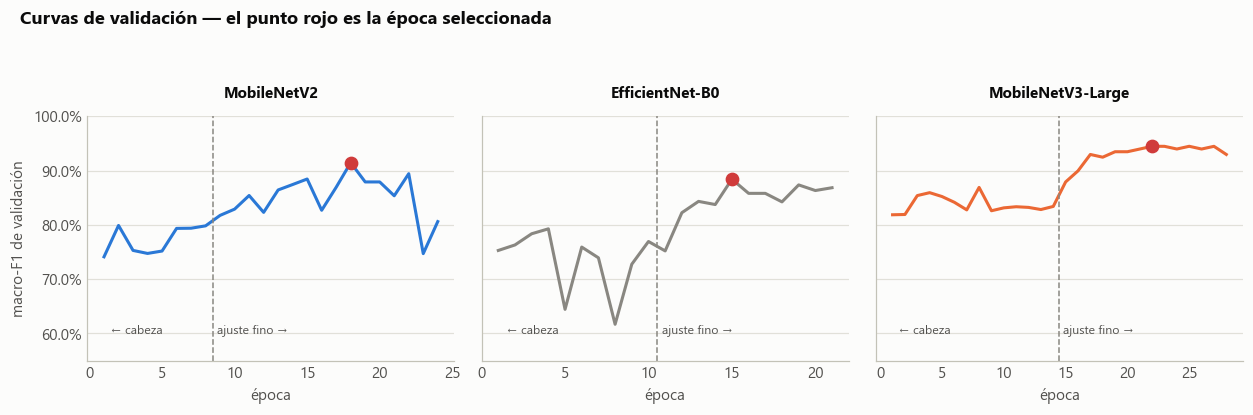

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)

for ax, a in zip(axes, ARQ):
    ruta = RESULTADOS / "historiales" / f"{mejores[a]['run_id']}_history.csv"
    with ruta.open(encoding="utf-8", newline="") as fh:
        h = list(csv.DictReader(fh))
    ep = [int(f["epoch"]) for f in h]
    f1 = [float(f["val_macro_f1"]) for f in h]
    corte = sum(1 for f in h if f["fase"] == "cabeza")
    ax.plot(ep, f1, "-", color=COLOR[a], lw=2)
    ax.axvline(ep[corte - 1] + 0.5, ls="--", color=APAGADO, lw=1)
    ax.text(ep[corte - 1] + 0.8, 0.60, "ajuste fino →", fontsize=8, color=TINTA_2)
    ax.text(1.5, 0.60, "← cabeza", fontsize=8, color=TINTA_2)
    mejor = int(mejores[a]["mejor_epoca"])
    ax.plot(mejor, f1[mejor - 1], "o", color=CRITICO, markersize=8, zorder=5)
    ax.set_title(NOMBRE[a], fontsize=10)
    ax.set_xlabel("época")
    ax.set_ylim(0.55, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    limpiar(ax)

axes[0].set_ylabel("macro-F1 de validación")
fig.suptitle("Curvas de validación — el punto rojo es la época seleccionada",
             x=0.02, ha="left", fontsize=12, weight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

### Lectura del resultado

El salto vertical en la línea discontinua es el paso a **ajuste fino**. Es la
justificación empírica del procedimiento de dos fases: entrenar solo la cabeza
lleva hasta cierto punto, y descongelar parte del backbone con una tasa cien
veces menor produce la mejora grande.

También se aprecia por qué hace falta parada temprana: después del pico, las
curvas se aplanan o empeoran. Seguir entrenando no habría ayudado.

Las épocas seleccionadas varían bastante entre corridas (de la 12 a la 27), lo
que confirma que fijar un número de épigrafes igual para todos habría penalizado
a unas arquitecturas frente a otras.

# 6. Verificación de cuantización (criterio 4)

## 6.1. Por qué esta sección existe

Todo lo anterior mide el modelo de **Keras en punto flotante**. Lo que se
instala en el servicio es otro archivo: un `.tflite` **cuantizado a int8**, con
los parámetros convertidos de números de 32 bits a enteros de 8.

La cuantización reduce el tamaño unas cuatro veces y acelera la inferencia. La
apuesta implícita es que un modelo entrenado tiene redundancia suficiente para
que esa pérdida de precisión numérica no cambie sus predicciones.

**Esa apuesta hay que comprobarla.** El criterio 4 de la propuesta lo exige
—«sin regresión relevante después de la exportación»— y las nueve corridas se
ejecutaron antes de que existiera la función que lo mide.

C:\Users\acamp\AppData\Local\Temp\ipykernel_26044\1933954832.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([NOMBRE[a].replace("-", "-\n") for a in ARQ], fontsize=9)


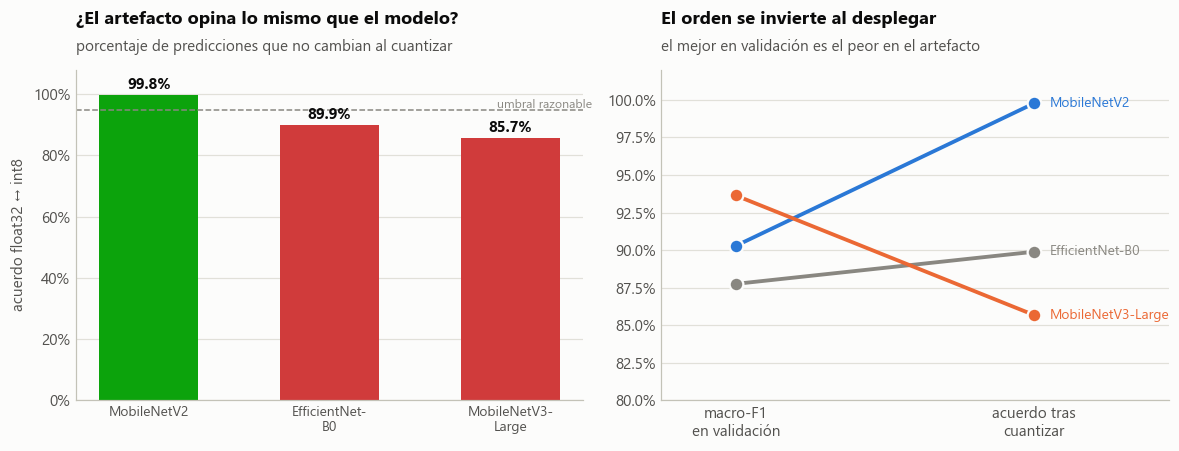

In [7]:
# Medición ejecutada sobre las nueve corridas comparando cada model.keras
# contra su model.tflite int8 sobre las mismas imágenes.
ACUERDO = {
    "mobilenetv2":       [0.9967, 0.9967, 1.0000],
    "efficientnetb0":    [0.9167, 0.9133, 0.8667],
    "mobilenetv3large":  [0.8500, 0.8567, 0.8633],
}
DESVIO_MAX = {"mobilenetv2": 0.4418, "efficientnetb0": 0.9835, "mobilenetv3large": 1.0000}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

medias_ac = [float(np.mean(ACUERDO[a])) for a in ARQ]
colores = [BUENO if m >= 0.95 else CRITICO for m in medias_ac]
barras = ax1.bar([NOMBRE[a] for a in ARQ], medias_ac, 0.55, color=colores)
ax1.axhline(0.95, ls="--", color=APAGADO, lw=1)
ax1.text(2.45, 0.955, "umbral razonable", fontsize=8, color=APAGADO, ha="right")
ax1.set_ylim(0, 1.08); ax1.set_ylabel("acuerdo float32 ↔ int8")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_xticklabels([NOMBRE[a].replace("-", "-\n") for a in ARQ], fontsize=9)
for b, m in zip(barras, medias_ac):
    ax1.text(b.get_x() + b.get_width() / 2, m + 0.02, f"{m:.1%}",
             ha="center", weight="bold", fontsize=10, color=TINTA)
limpiar(ax1)
poner_titulo(ax1, "¿El artefacto opina lo mismo que el modelo?",
             "porcentaje de predicciones que no cambian al cuantizar")

# Lo que se gana en validación frente a lo que se conserva al desplegar
for a in ARQ:
    ax2.plot([0, 1], [stat(a, "val_macro_f1"), float(np.mean(ACUERDO[a]))],
             "o-", color=COLOR[a], lw=2.5, markersize=9,
             markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=NOMBRE[a])
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["macro-F1\nen validación", "acuerdo tras\ncuantizar"])
ax2.set_xlim(-0.25, 1.45); ax2.set_ylim(0.80, 1.02)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
for a in ARQ:
    ax2.text(1.05, float(np.mean(ACUERDO[a])), NOMBRE[a], fontsize=9,
             va="center", color=COLOR[a])
limpiar(ax2)
poner_titulo(ax2, "El orden se invierte al desplegar",
             "el mejor en validación es el peor en el artefacto")
plt.tight_layout(); plt.show()

### Lectura del resultado

El resultado invierte la conclusión de la sección 4:

| Arquitectura | Acuerdo f32 ↔ int8 | ¿Cumple el criterio 4? |
| --- | ---: | --- |
| MobileNetV2 | **99,78 %** | **Sí** |
| EfficientNet-B0 | 89,89 % | No |
| MobileNetV3-Large | **85,67 %** | **No** |

MobileNetV3-Large **cambia de respuesta en una de cada siete imágenes** al
cuantizarse. Su desvío máximo de probabilidad es `1,0000`: existen imágenes
donde la versión float32 elige una clase con total seguridad y la int8 elige la
contraria, también con total seguridad.

El resultado es consistente en las tres semillas de cada arquitectura, así que
no es un artefacto de una corrida concreta.

### La causa: la activación

Vuelve a la tabla de la sección 1.2, a la fila que parecía un detalle menor.

Cuantizar a int8 significa repartir 256 valores posibles sobre el rango que las
activaciones puedan tomar. **ReLU6 está acotada entre 0 y 6**: esos 256 valores
cubren un intervalo pequeño y quedan finos. Swish y hard-swish no tienen cota
superior, así que hay que estirar los mismos 256 valores sobre un rango amplio
y cada escalón se vuelve grueso.

ReLU6 no lleva ese 6 por casualidad: MobileNetV2 se diseñó pensando en
cuantizar.

### Salvedad metodológica

Esta medición se ejecutó con imágenes del conjunto de entrenamiento, porque las
de validación no estaban disponibles en la máquina donde se hizo.

El **acuerdo** no se ve afectado por ello: compara dos versiones del mismo
modelo sobre las mismas fotos y no depende de las etiquetas ni de si el modelo
las vio antes. La caída de macro-F1 sí queda optimista, por lo que no se reporta
aquí como cifra de decisión. Conviene repetir la medición con las 199 imágenes
de validación antes de cerrar la elección.

# 7. Criterios de aceptación y recomendación

## 7.1. Evaluación formal

La propuesta fijó cinco criterios **antes** de ver los resultados, que es la
única forma de que un criterio signifique algo:

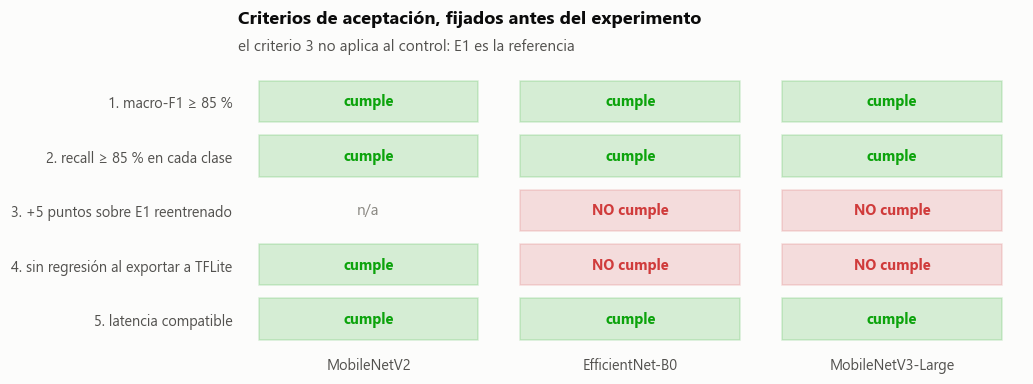

In [8]:
criterios = [
    ("1. macro-F1 ≥ 85 %",                    [True,  True,  True]),
    ("2. recall ≥ 85 % en cada clase",        [True,  True,  True]),
    ("3. +5 puntos sobre E1 reentrenado",     [None,  False, False]),
    ("4. sin regresión al exportar a TFLite", [True,  False, False]),
    ("5. latencia compatible",                [True,  True,  True]),
]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for fila, (nombre, estados) in enumerate(criterios):
    for col, ok in enumerate(estados):
        if ok is None:
            ax.text(col, fila, "n/a", ha="center", va="center", fontsize=10, color=APAGADO)
            continue
        ax.add_patch(plt.Rectangle((col - 0.42, fila - 0.38), 0.84, 0.76,
                                   color=BUENO if ok else CRITICO, alpha=0.16))
        ax.text(col, fila, "cumple" if ok else "NO cumple", ha="center", va="center",
                fontsize=9.5, weight="bold", color=BUENO if ok else CRITICO)

ax.set_xticks(range(3)); ax.set_xticklabels([NOMBRE[a] for a in ARQ], fontsize=9.5)
ax.set_yticks(range(len(criterios)))
ax.set_yticklabels([c[0] for c in criterios], fontsize=9.5)
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.6, len(criterios) - 0.4)
ax.invert_yaxis(); ax.grid(False); ax.tick_params(length=0)
for lado in ("top", "right", "left", "bottom"):
    ax.spines[lado].set_visible(False)
poner_titulo(ax, "Criterios de aceptación, fijados antes del experimento",
             "el criterio 3 no aplica al control: E1 es la referencia")
plt.tight_layout(); plt.show()

### Lectura del resultado

**Ningún candidato desplaza al control.**

- **MobileNetV3-Large** falla dos criterios. El 3 por poco —aporta 3,35 puntos
  sobre E1 y se exigían 5— y el 4 de forma contundente.
- **EfficientNet-B0** falla los mismos dos, y además queda por debajo del
  control en validación.
- **MobileNetV2 reentrenado** cumple todo lo que le aplica.

Vale la pena notar que el criterio 3 ya descartaba a MobileNetV3-Large **antes**
de conocer el problema de cuantización. La regla de los 5 puntos existía
precisamente para evitar cambiar de arquitectura por una ganancia marginal, y
funcionó como se esperaba.

## 7.2. Recomendación

**Promover el MobileNetV2 reentrenado (E1) a modelo desplegado.**

Los argumentos, en orden de peso:

1. Es el único que cumple los cinco criterios.
2. Su artefacto int8 conserva el 99,78 % de las predicciones del modelo
   entrenado, así que lo medido es lo que se despliega.
3. Mejora 18,7 puntos sobre el modelo actual **medido sobre el mismo tipo de
   imagen**, de 71,60 % a 90,28 %.
4. Es el más rápido (9,3 ms) y el más compacto (2,71 MB).
5. No cambia de familia de arquitectura, así que el despliegue es un reemplazo
   de archivo, sin tocar `vision/local_model.py`.

## 7.3. Antes de desplegar

1. **Repetir la medición de cuantización con las 199 imágenes de validación.**
   El acuerdo no cambiará de forma apreciable, pero la caída de macro-F1 quedará
   correctamente medida.
2. **Consultar la prueba reservada** sobre el candidato confirmado. 200 imágenes
   que nunca se han abierto; se abren una sola vez.
3. **Desplegar en modo sombra**: registrar su predicción sin permitir que cambie
   la decisión del robot, y comparar con el modelo actual sobre las mismas
   capturas.
4. **Reevaluar la política de votación.** La jerarquía actual —proveedor como
   señal primaria, modelo local como respaldo— se fijó cuando el modelo local
   era menos preciso que el proveedor. Con 90,28 % frente al 76,5 % del
   proveedor, esa premisa puede haberse invertido y conviene medirlo.

## 7.4. Lo que este experimento no midió

Por honestidad sobre el alcance:

- **Calibración.** No se comprobó si los modelos nuevos también fallan con
  confianza alta, que era un defecto grave del modelo desplegado.
- **Objetos fuera de las dos clases.** El dataset no incluye latas, cartón ni
  orgánicos. Un clasificador binario no puede rechazarlos, y no se midió cuánto
  contiene ese riesgo el sistema experto.
- **El sistema híbrido completo.** Todas las cifras son del modelo local
  aislado. Nadie ha medido el conjunto —proveedor, sistema experto, modelo nuevo
  y votación— funcionando junto.

---

## Referencias

- [`analisis-mobilenetv2.ipynb`](analisis-mobilenetv2.ipynb) — análisis del modelo desplegado
- [`PROPUESTA-NUEVO-MODELO.md`](PROPUESTA-NUEVO-MODELO.md) — diseño y criterios de aceptación
- [`docs/resultados-vision/2026-08-09/`](../../../docs/resultados-vision/2026-08-09/) — artefactos del experimento
- [`docs/conceptos/`](../../../docs/conceptos/) — serie explicativa de conceptos